In [1]:
import argparse
import os
import sys
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
INPUT_DIR = "../../data/embedded"
LABELS_PATH = "../../data/preprocessed/cleaned_labels.csv"
OUTPUT_DIR = "../../data/results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def load_data_recursive(input_dir):
    embeddings_list = []
    filenames = []

    print(f"Scanning '{input_dir}' for embeddings...")
    files_found = 0
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".npy"):
                file_path = os.path.join(root, file)
                try:
                    data = np.load(file_path)

                    if data.ndim == 0:
                        continue
                    elif data.ndim == 2:
                        data = data.squeeze()

                    if data.shape != (1024,):
                        continue

                    embeddings_list.append(data)

                    filenames.append(file.replace(".npy", ""))
                    files_found += 1
                except Exception as e:
                    print(f"Error occured, with message: {e}...")

    if files_found == 0:
        return None, None

    print(f"Found {files_found} valid files.")
    return np.vstack(embeddings_list), filenames

In [4]:
X, file_labels = load_data_recursive(INPUT_DIR)

if X is None:
    print("ERROR: No valid embeddings found!")
else:
    df_data = pd.DataFrame(X)
    df_data['ecg_id'] = np.array(file_labels).astype(int)

    print("Loading ground truth labels...")
    try:
        true_labels_df = pd.read_csv(LABELS_PATH)
        df_merged = df_data.merge(true_labels_df[["ecg_id", "label"]], on="ecg_id", how="inner")

        df_merged = df_merged.dropna(subset=["label"])

        y = df_merged["label"].values
        X_final = df_merged.drop(columns=["ecg_id", "label"]).values

        print(f"Final dataset ready: {X_final.shape[0]} samples, {X_final.shape[1]} feature, {len(np.unique(y))} classes.")
    except Exception as e:
        print(f"Error loading labels: {e}")

Scanning '../../data/embedded' for embeddings...
Found 16272 valid files.
Loading ground truth labels...
Final dataset ready: 16272 samples, 1024 feature, 5 classes.


In [5]:
print("Scaling features and splittiong data (80/20)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Scaling features and splittiong data (80/20)...
Training set: 13017 samples
Testing set: 3255 samples


In [6]:
print("--- Logistic Regression (Linear Baseline) ---") # Linear Probe

lr_model = LogisticRegression(max_iter = 1000, random_state = 42, class_weight = "balanced")
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print("Detailed classification report:")
print(classification_report(y_test, lr_pred))

--- Logistic Regression (Linear Baseline) ---
Accuracy: 66.64%
Detailed classification report:
              precision    recall  f1-score   support

          CD       0.56      0.75      0.64       342
         HYP       0.12      0.34      0.17       107
          MI       0.62      0.65      0.63       508
        NORM       0.87      0.67      0.76      1817
        STTC       0.59      0.70      0.64       481

    accuracy                           0.67      3255
   macro avg       0.55      0.62      0.57      3255
weighted avg       0.73      0.67      0.69      3255



In [12]:
print("--- Random Forest (Non-Linear Baseline) ---")

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = 1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print("Detailed classification report:")
print(classification_report(y_test, rf_pred))

--- Random Forest (Non-Linear Baseline) ---
Accuracy: 74.44%
Detailed classification report:
              precision    recall  f1-score   support

          CD       0.90      0.52      0.66       342
         HYP       0.00      0.00      0.00       107
          MI       0.67      0.47      0.55       508
        NORM       0.76      0.95      0.84      1817
        STTC       0.66      0.58      0.62       481

    accuracy                           0.74      3255
   macro avg       0.60      0.50      0.53      3255
weighted avg       0.72      0.74      0.72      3255



In [13]:
def plot_confusion_matrix(y_test, predictions_to_plot, model_classes, model_name):
    cm = confusion_matrix(y_test, predictions_to_plot, labels = model_classes)

    cm_df = pd.DataFrame(cm, index = model_classes, columns = model_classes)
    
    fig = px.imshow(
        cm_df,
        text_auto = True,
        color_continuous_scale = "Blues",
        labels = dict(x = "Predicted Diagnosis", y = "True Diagnosis", color = "Count"),
        x = model_classes,
        y = model_classes,
        title = f"Confusion Matrix: {model_name} on MOMENT Embeddings"
    )
    
    fig.update_layout(template = "plotly_white")
    
    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_{model_name.replace(' ', '_').lower()}.html")
    fig.write_html(cm_path)
    print(f"Saved interactive confusion matrix to: {cm_path}")
    
    fig.show()

Saved interactive confusion matrix to: ../../data/results\confusion_matrix_logistic_regression.html


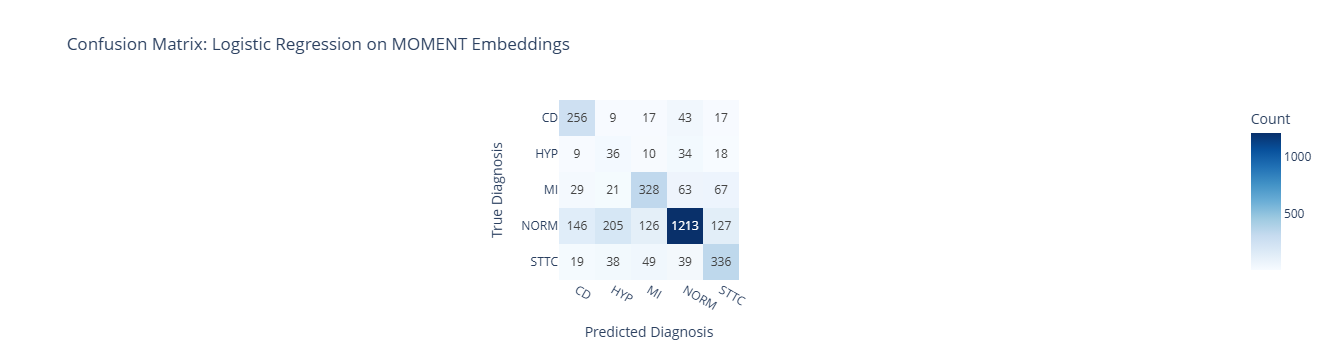

In [14]:
plot_confusion_matrix(y_test, lr_pred, lr_model.classes_, "Logistic Regression")

Saved interactive confusion matrix to: ../../data/results\confusion_matrix_random_forest.html


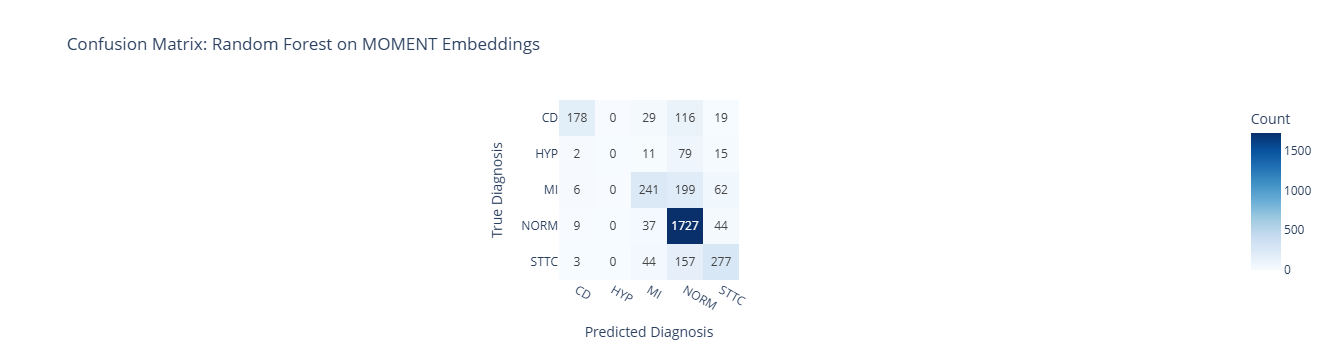

In [15]:
plot_confusion_matrix(y_test, rf_pred, rf_model.classes_, "Random Forest")

Statikus tévesztési mátrix mentve ide: ../../data/results\confusion_matrix_random_forest.png


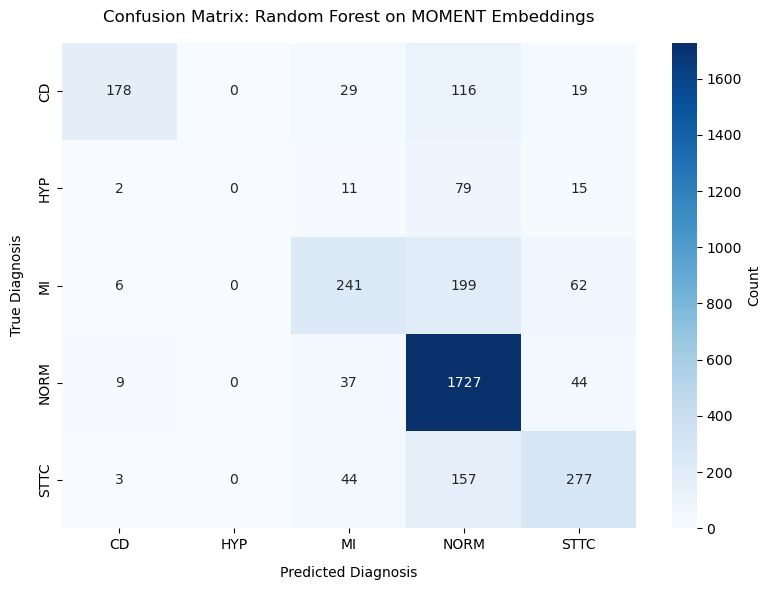

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_,
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix: Random Forest on MOMENT Embeddings', pad=15)
plt.xlabel('Predicted Diagnosis', labelpad=10)
plt.ylabel('True Diagnosis', labelpad=10)
plt.tight_layout()

cm_path_png = os.path.join(OUTPUT_DIR, "confusion_matrix_random_forest.png")
plt.savefig(cm_path_png, dpi=300, bbox_inches='tight')
print(f"Statikus tévesztési mátrix mentve ide: {cm_path_png}")

plt.show()